## MECHA

### Computing the root hydraulic properties

MECHA is an explicit cross-section model of the root hydraulic anatomy which connects hydraulic concepts across scales.

### Run MECHA


In [1]:
%cd ..

/mnt/c/Users/heymansad/OneDrive - UCL/Documents/GitHub/HydroNeedle/MECHA-dev


In [2]:
from src.utils.data_loader import *

In [4]:
AllIn = InData(cellset_file="extdata/current_root.xml")

AllIn.info()

Setting default boundary conditions...

=== InData Configuration Summary ===

File Paths:
  Boundary file: Using defaults
  General file: Using defaults
  Geometry file: Using defaults
  Hormones file: Using defaults
  Hydraulics file: Using defaults
  Cellset file: extdata/current_root.xml

Boundary Configuration:
  Number of scenarios: 1
  Solute transport flag: False

General Configuration:
  Symplastic contagion: 0
  Apoplastic contagion: 0
  Particle tracking: 0

Geometry Configuration:
  Plant name: 
  Image scale: 1000.0
  Number of maturity stages: 1
  Passage cell IDs: [-1]
  Cell wall thickness: 1.5 µm
  Plasmodesmata section: 7.47e-05 µm²

Hormones Configuration:
  Degradation constant: 48.0
  PD diffusivity: 0.0035
  PW diffusivity: 0.0035
  D2O flag: False
  Number of carriers: 1

Hydraulic Configuration:
  Number of scenarios: 1
  Membrane conductivity: 3e-05
  kAQP: [{'value': 0.00043, 'cortex_factor': 1.0, 'endo_factor': 1.0, 'epi_factor': 1.0, 'exo_factor': 1.0, 'stele

### Preview section


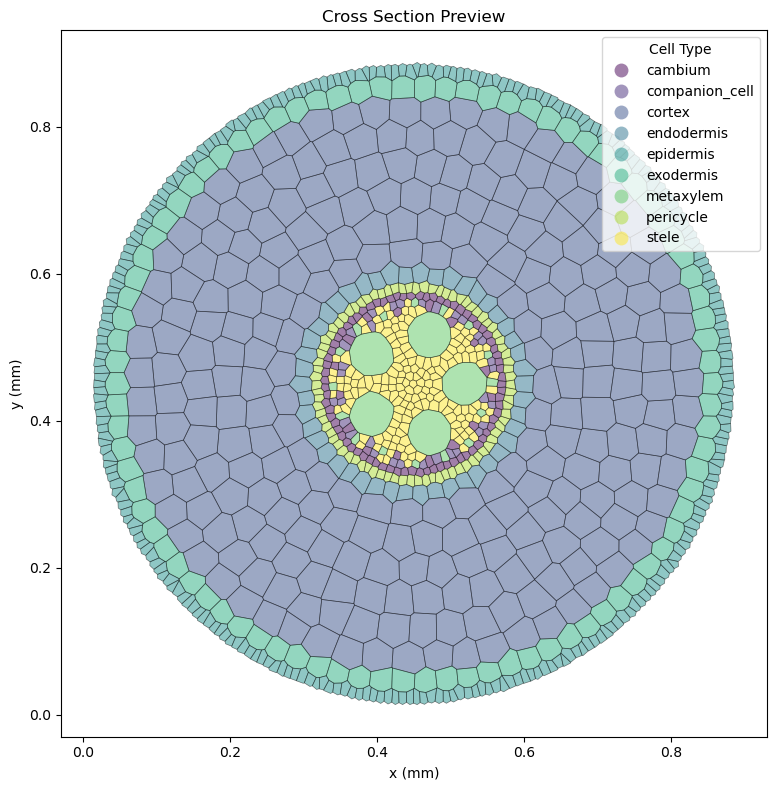

In [5]:
from src.utils.visu import *

visualize(AllIn.cellset_data, "polygon")


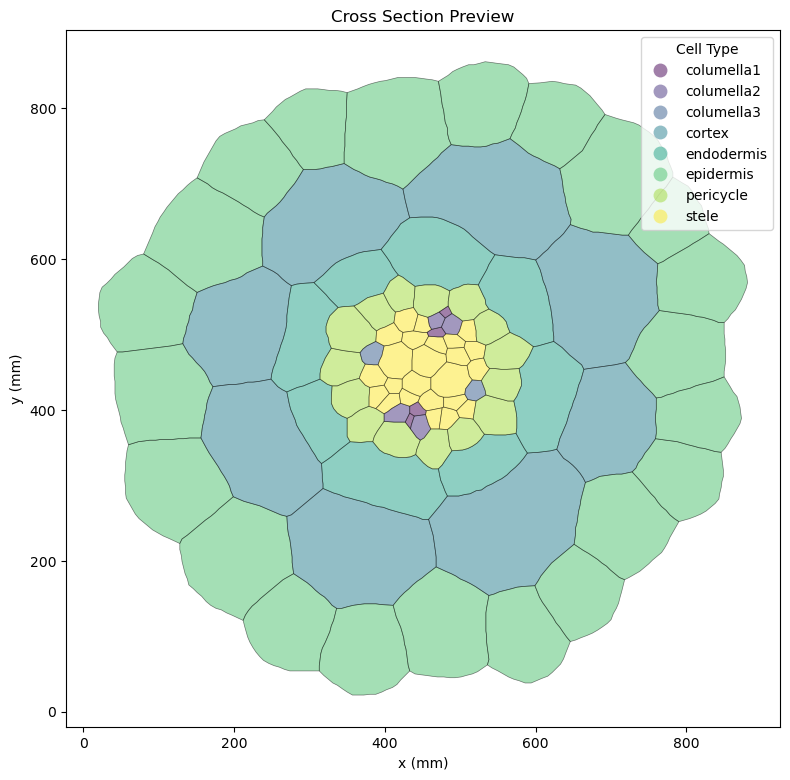

In [6]:
Arabidopsis = parse_cellset("./tutorials/tutorial_data/Arabidopsis.xml")
visualize(Arabidopsis, "polygon")

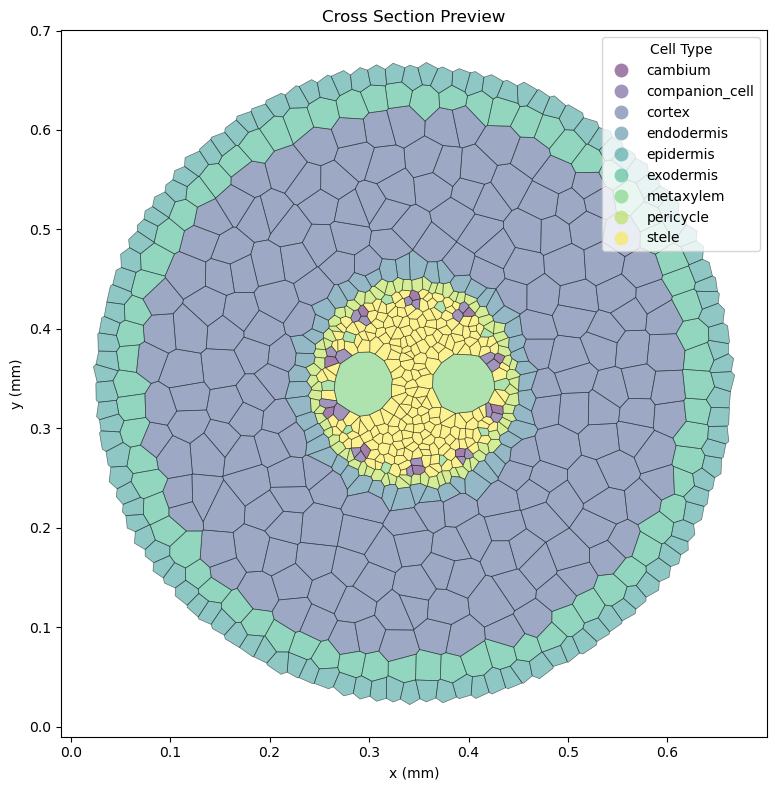

In [11]:
sorghum = parse_cellset("./tutorials/tutorial_data/sorghum_7cm.xml")
visualize(sorghum, "polygon")

In [7]:
from src.utils.network_builder import *
import networkx as nx

section_nx = NetworkBuilder()
section_nx.build_network(AllIn.general, AllIn.geometry, Arabidopsis)

position=nx.get_node_attributes(section_nx.graph,'position') #Updates nodes XY positions (micrometers)
indice=nx.get_node_attributes(section_nx.graph,'indice') #Node indices (walls, junctions and cells)

  Creating wall, junction and cell nodes...
  Creating membrane connections...
  Ranking cells by tissue type and distance from root center...


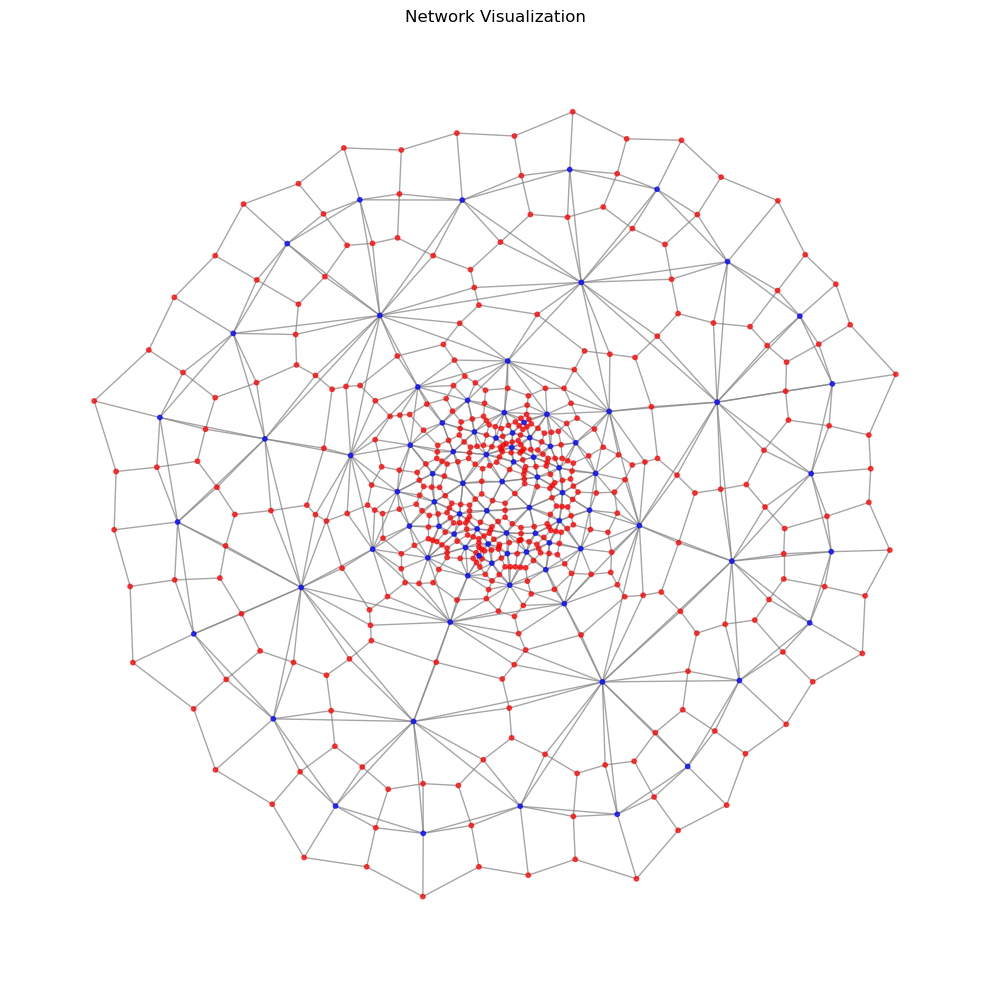

In [8]:
visualize(section_nx, "network")

In [10]:
AllIn.boundary.n_kw

AttributeError: 'BoundaryData' object has no attribute 'n_kw'

In [11]:
section_maize = mecha(AllIn)

visualize(section_maize.bc, "osmotic_pot")

section_maize.solve()

kr_1 = section_maize.kr[0]
kr_3 = section_maize.kr[1]

visualize(section_maize.solution[0], "wall")

visualize(section_maize.partition[0])


NameError: name 'mecha' is not defined

In [12]:
info = {'STUF' : Hydr.STFlayer_plus,
        'STRF' : Hydr.STFlayer_minus, 
        'dist' : Hydr.Layer_dist2,
        'type' : Hydr.cell_type}
df = pd.DataFrame(data = info)
df = df[::-1].reset_index(drop=True)
df['STF diff'] = df['STUF']-df['STRF']
df['STF'] = df['STF diff'].cumsum()
df['cell_spacing'] = df['dist'].diff()

poly = Macro_hydro_visu.poly_table(df)
Macro_hydro_visu.graph_apo_symp(poly)

NameError: name 'Hydr' is not defined

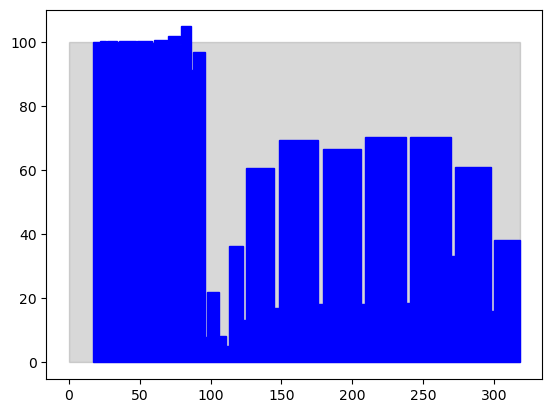

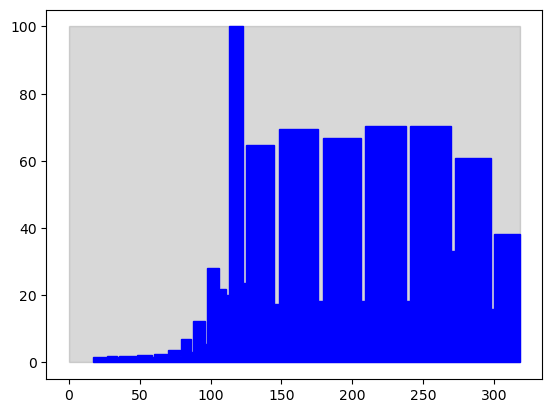

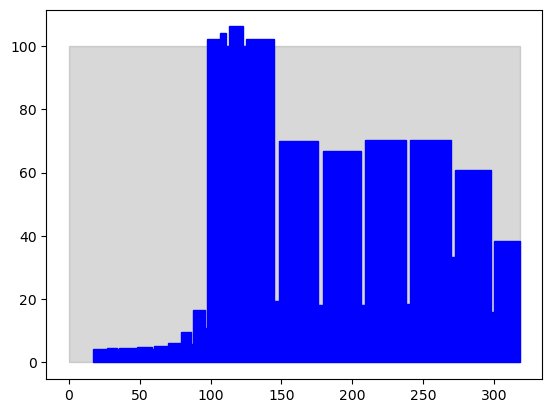

In [13]:
# Set the folder path where the .txt files are located
folder_path = os.path.join(dir, Project, "out/Tomato/Root/Project_Test/results/")

# Loop through all .txt files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt") & file_name.startswith("Macro_prop"):  # Check if the Macro_prop file is a .txt file
        file_path = os.path.join(folder_path, file_name)  # Full path to the file
        
        # Open and read the file
        with open(file_path, "r") as file:
            # Read the contents of the file
            fl = file.read()
        
        # Call your plot function with the file content
        plot_partition(fl)

In [19]:
#Project
Project ='Projects/maize_granar/' 

# Run MECHA
MECHA_run(dir, Project)

Importing Data
0.5602447110004505 seconds process time
Initializing network
Identifying soil-root interface walls
Getting X and Y cell nodes
0.6448194920003516 seconds process time
Creating network connections
12.978253702000075 seconds process time
Computing cortex AQP parameters
0.08688259400059906 seconds process time
Maturity #0 with apoplastic barrier type #1
Maturity #1 with apoplastic barrier type #2
Maturity #2 with apoplastic barrier type #4
4.065473115999339 seconds process time


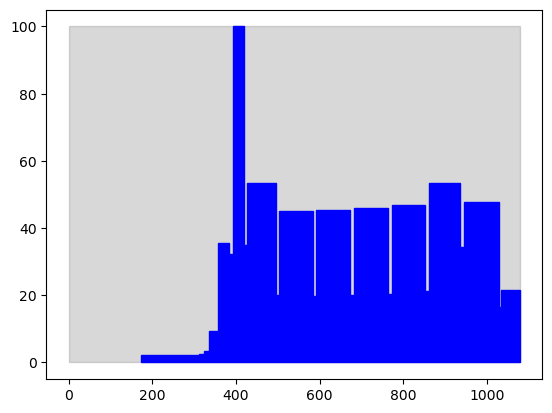

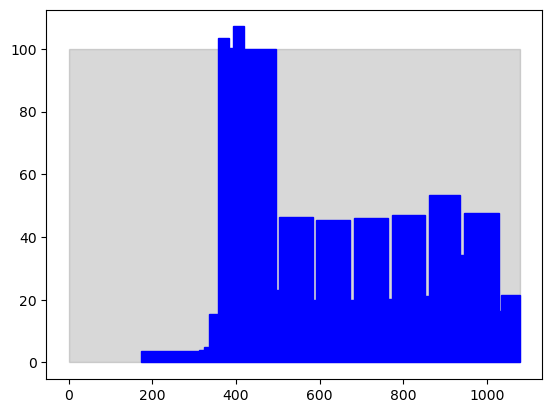

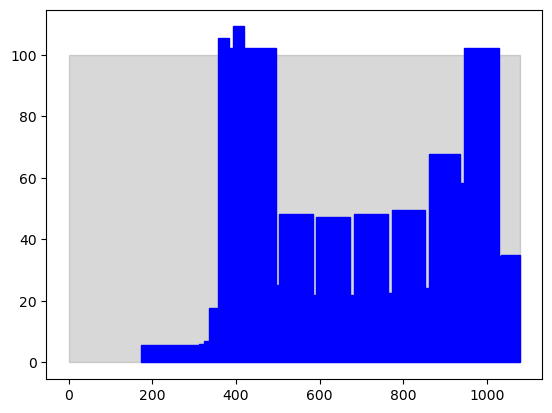

In [17]:
# Set the folder path where the .txt files are located
folder_path = os.path.join(dir, Project, "out/M1v4/Root/Project_Test/results/")

# Loop through all .txt files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt") & file_name.startswith("Macro_prop"):  # Check if the Macro_prop file is a .txt file
        file_path = os.path.join(folder_path, file_name)  # Full path to the file
        
        # Open and read the file
        with open(file_path, "r") as file:
            # Read the contents of the file
            fl = file.read()
        
        # Call your plot function with the file content
        plot_partition(fl)